In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
resumes = pd.read_parquet('processed/resume_embeddings.parquet')
jobs = pd.read_parquet('processed/dice_job_descriptions_embeddings.parquet')

In [5]:
resumes

,ID,Resume_str,Resume_html,Category,extracted_skills,length,matched_skills,matched_skills_ordered,skill_embeddings,skill_embeddings_ordered,avg_skill_embedding
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,"[Accounting, Ads, Advertising, Analytical skil...",5442,"[accounting, create advertisements, outdoor ad...","[accounting, company policies, conduct public ...","[-0.051119804, 0.051380936, -0.1956489, -0.000...","[-0.028823888, 0.056566164, -0.19899392, -0.00...","[0.0002473207458333337, 0.03493942622916666, -..."
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,"[Adobe Photoshop, ADP, Asset Management, brand...",5572,"[Adobe Photoshop, asset management, maintain c...","[Adobe Illustrator, Adobe Photoshop, asset man...","[-0.013715399, 0.01982399, -0.15967667, 0.0198...","[-0.02063493, 0.030683268, -0.16921557, 0.0126...","[0.002284706435294118, 0.01609132022352941, -0..."
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,"[Recruiting, FMLA/EEO/FLSA, HRIS Development, ...",7720,"[recruit members, foreign affairs policy devel...","[Microsoft Access, desktop publishing, foreign...","[-0.037161566, 0.0036097213, -0.19848743, -0.0...","[0.0076125017, 0.01415186, -0.17561796, -0.009...","[-0.0002954738888888898, 0.02081807622222222, ..."
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,"[Type 50 wpm and 10-Key by touch, Microsoft pr...",2855,"[personnel management, customer service, resol...","[customer service, personnel management, resol...","[-0.004071229, -0.0062129777, -0.16848274, -0....","[-0.0024955925, -0.005882781, -0.17091864, -0....","[0.007837255066666667, 0.0018740463333333332, ..."
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,"[ADA, ADP, art, agency, benefits, Benefits Adm...",9172,"[create artwork, coaching techniques, coaching...","[Microsoft Access, Microsoft Visio, coaching t...","[0.008319367, 0.02057786, -0.17201392, 0.01393...","[4.8317004e-05, 0.005026085, -0.17149556, 0.01...","[0.00895575635652174, 0.013967274808695652, -0..."
...,...,...,...,...,...,...,...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,"[Secret Clearance, Stock Control, Management, ...",5533,"[follow stock control instructions, operations...","[communication, follow stock control instructi...","[0.0049826736, 0.0045687603, -0.19545835, -0.0...","[0.0075103026, -0.0060989116, -0.19636096, -0....","[0.007711735449999999, 0.005379060733333334, -..."
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION,"[arbitration, agency, budgets, Budget, continu...",7108,"[examine budgets, update budget, continuous im...","[Microsoft Visio, computer graphics, continuou...","[0.04153785, 0.038161203, -0.16648234, -0.0115...","[0.048209656, 0.025236994, -0.15883973, -0.005...","[0.013527077672727272, 0.028311003981818184, -..."
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,"[Active Directory, Hardware, Customer Service,...",2020,"[hardware materials, customer service, manage ...","[assemble windows, customer service, hardware ...","[0.010476048, 0.028934365, -0.16972545, 0.0036...","[0.010129859, 0.025989288, -0.16765723, 0.0025...","[0.025738319725, 0.032416258287500006, -0.1611..."
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,"[Adobe, CPR, Customer Service, Customer Care, ...",5074,"[customer service, maintain customer service, ...","[Microsoft Access, chair a meeting, customer s...","[-0.013092378, 0.055586472, -0.17801957, -0.01...","[-0.006703326, 0.049669117, -0.16404499, -0.01...","[-0.003938775142857142,

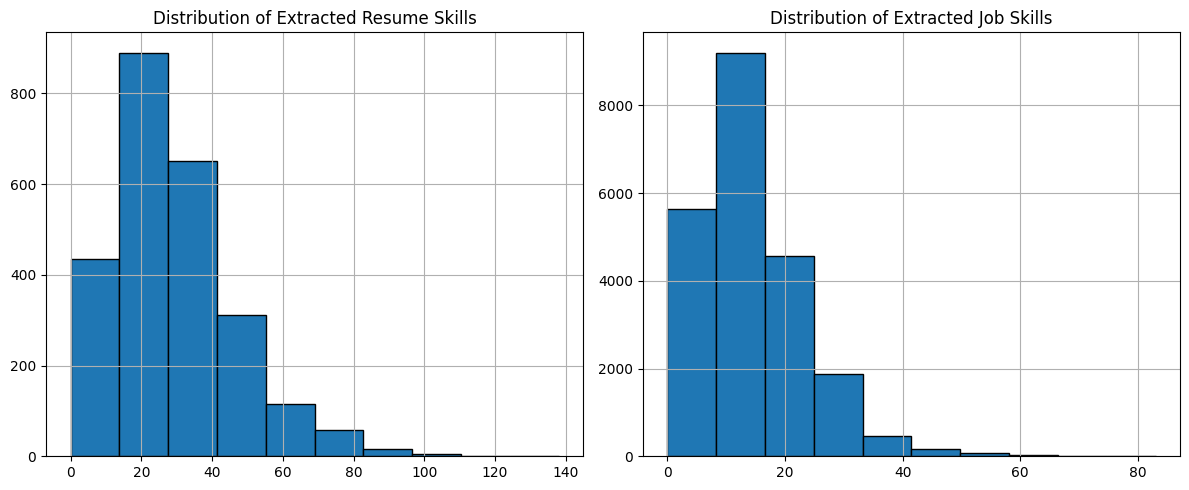

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    resumes['extracted_skills'].str.len(),
    edgecolor='black'
)
axes[0].set_title('Distribution of Extracted Resume Skills')
axes[0].grid()

axes[1].hist(
    jobs['extracted_skills'].str.len(),
    edgecolor='black'
)
axes[1].set_title('Distribution of Extracted Job Skills')
axes[1].grid()

plt.tight_layout()
plt.show()

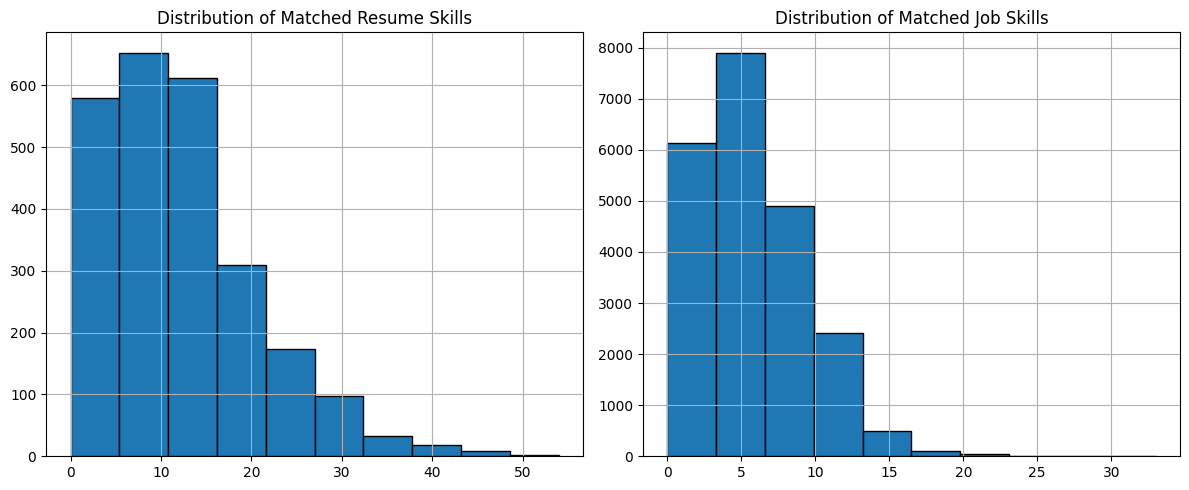

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    resumes['matched_skills'].str.len(),
    edgecolor='black'
)
axes[0].set_title('Distribution of Matched Resume Skills')
axes[0].grid()

axes[1].hist(
    jobs['matched_skills'].str.len(),
    edgecolor='black'
)
axes[1].set_title('Distribution of Matched Job Skills')
axes[1].grid()

plt.tight_layout()
plt.show()

In [21]:
esco = pd.read_parquet('processed/esco_skills.parquet')

In [23]:
esco

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,embeddings
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,manage staff of music\ncoordinate duties of mu...,None,released,2023-11-30T15:53:37.136Z,None,None,http://data.europa.eu/esco/concept-scheme/skil...,Assign and manage staff tasks in areas such as...,"[-0.054591812, -0.018804703, -0.17031825, -0.0..."
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,oversee prison procedures\nmanage correctional...,None,released,2023-11-30T15:04:00.689Z,None,None,http://data.europa.eu/esco/concept-scheme/memb...,Supervise the operations of a correctional fac...,"[0.048651647, 0.023129402, -0.14121306, -0.031..."
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,apply non-oppressive practices\napply an anti-...,None,released,2023-11-28T10:45:53.54Z,None,None,http://data.europa.eu/esco/concept-scheme/skil...,"Identify oppression in societies, economies, c...","[0.042062778, 0.018910391, -0.16224517, -0.035..."
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,control compliance of railway vehicles regulat...,monitoring of compliance with railway vehicles...,None,released,2023-11-30T16:29:18.273Z,None,None,http://data.europa.eu/esco/concept-scheme/skil...,"Inspect rolling stock, components and systems ...","[-0.020243065, -0.01827101, -0.17690042, 0.008..."
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,identify available services,establish available services\ndetermine rehabi...,None,released,2023-11-28T10:38:49.206Z,None,None,http://data.europa.eu/esco/concept-scheme/memb...,Identify the different services available for ...,"[-0.069251984, -0.0001897157, -0.15665601, -0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13934,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/ffef5eb3-a15e...,skill/competence,sector-specific,remediate healthcare user's occupational perfo...,restore healthcare user's occupational perform...,None,released,2024-02-09T17:29:15.235Z,None,None,http://data.europa.eu/esco/concept-scheme/memb...,"Remediate or restore the cognitive, sensorimot...","[-0.01614617, 0.00750463, -0.18048497, -0.0251..."
13935,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0b074-5a76...,skill/competence,sector-specific,install transport equipment lighting,install transport equipment illumination\nfix ...,None,released,2024-02-09T17:29:14.494Z,None,None,http://data.europa.eu/esco/concept-scheme/skil...,Install lighting elements in transport equipme...,"[-0.049296044, 0.03540551, -0.18445863, -0.021..."
13936,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0e2cd-d0bd...,knowledge,sector-specific,natural language processing,NLP,None,released,2024-02-09T17:29:15.235Z,None,None,http://data.europa.eu/esco/concept-scheme/skil...,The technologies which enable ICT devices to u...,"[0.026312111, 0.021747442, -0.11412781, -0.073..."
13937,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff5bc45-b506...,skill/competence,cross-sector,coordinate construction activities,reviewing construction progress\nconstruction ...,None,released,2024-02-09T17:29:13.7Z,None,None,http://data.europa.eu/esco/concept-scheme/skil...,Coordinate the activities of several construct...,"[-0.009615241, 0.0053697606, -0.16515373, -0.0..."
